In [35]:
import networkx as nx
import matplotlib.pyplot as plt

In [1]:
# Fungsi pendukung untuk mencetak graf
def show_graph(G, pos=None, title='') :
  # Membuat pos jika pos tidak diberikan
  if pos is None:
      pos = nx.spring_layout(G)
  
  # Fungsi untuk menggambar node
  nx.draw(
      G,                  # Graf NetworkX
      pos,                # Posisi node
      with_labels=True,   # Menampilkan nama node 
      node_color='red',   # Warna node
      node_size=400,     # Ukuran node
      font_color="white", # Warna font label node
      font_weight="bold", # Ketebalan font label node
      width=5             # Ketebalan garis edge
  )

  # Mengambil label edge jika ada weight
  edge_labels = nx.get_edge_attributes(G, 'weight')  
  # Fungsi untuk menggambar node
  nx.draw_networkx_edge_labels(
      G,
      pos,
      edge_labels=edge_labels, # Data weight
      font_color='blue',       # Warna font label edge
      font_weight="bold",      # Berat font label edge
      font_size=16,            # Ukuran font label edge
  )

  plt.margins(0.2)  # Memberikan margin pada plot
  plt.title(title)  # Menampilkan judul graf jika diberikan
  plt.show()        # Menampilkan graf menggunakan matplotlib



In [37]:
pos = {
    'C' : (0,0),
    'D' : (-1,-3),
    'B' : (-2,4),
    'A' : (4,7),
    'E' : (2,-1),
}

In [38]:
city = nx.Graph()

In [39]:
nodes = ['A', 'B', 'C', 'D', 'E',]

In [41]:
city.add_nodes_from(nodes)

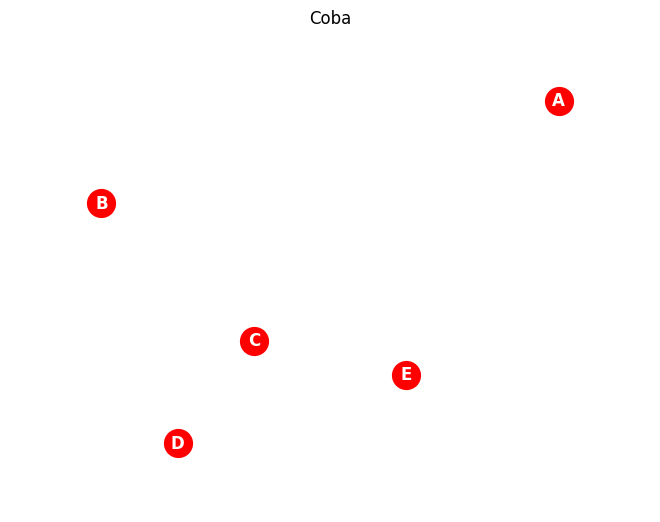

In [42]:
show_graph(city, pos=pos, title="Coba")

In [43]:
edges = [
    ('C', 'D', 4),
    ('C', 'B', 6),
    ('C', 'A', 12),
    ('C', 'E', 2),
    ('B', 'D', 9),
    ('E', 'A', 8),
]

In [60]:
for source, destiny, weight in edges:
    city.add_edge(source, destiny, weight=weight)

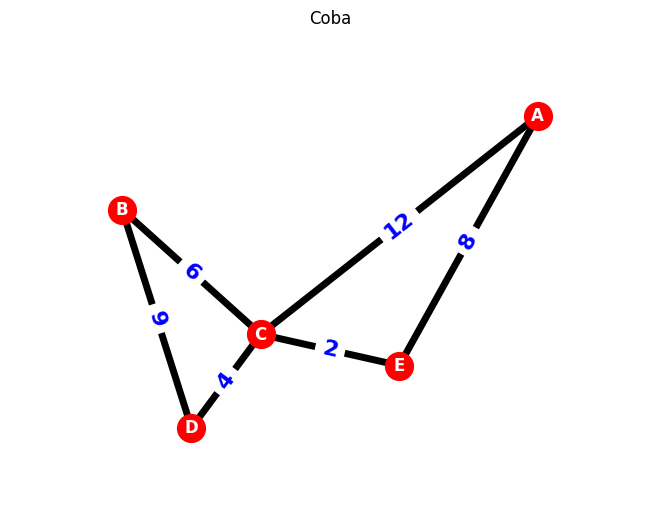

In [45]:
show_graph(city, pos=pos, title="Coba")

In [46]:
print(list(city.nodes))

['A', 'B', 'C', 'D', 'E']


In [48]:
for source, destiny, data in city.edges(data=True):
    print("from", source, "to", destiny, "is", data['weight'])

from A to C is 12
from A to E is 8
from B to C is 6
from B to D is 9
from C to D is 4
from C to E is 2


In [49]:
bfs_edge = list(nx.bfs_edges(city, source='C'))
print(list(bfs_edge))

[('C', 'D'), ('C', 'B'), ('C', 'A'), ('C', 'E')]


In [51]:
def bfs_search(bfs_tree, start, end):
    path = []
    current_node = end

    while current_node != start:
        path.append(current_node)
        current_node = bfs_tree[current_node]

    path.append(start)
    path.reverse()

    return path

In [57]:
def calculate_distance(graph, path):
    total_dist = 0

    for i in range (len(path) - 1):
        start_node = path[i]
        destiny_node = path[i + 1]

        total_dist += graph[start_node][destiny_node]['weight']

    return total_dist

In [54]:
start_node = input("Titik Awal :")
end_node = input("Titik Tujuan :")

bfs_tree = nx.bfs_tree(city, source=start_node)
bfs_edge = list(bfs_tree.edges())

print(f"{start_node} disimpan sebagai lokasi awal")
print(f"{end_node} disimpan sebagai lokasi tujuan")
print("Hasil pencarian BFS dari lokasi awal:", bfs_edge)

Titik Awal : B
Titik Tujuan : A


B disimpan sebagai lokasi awal
A disimpan sebagai lokasi tujuan
Hasil pencarian BFS dari lokasi awal: [('B', 'C'), ('B', 'D'), ('C', 'A'), ('C', 'E')]


In [55]:
bfs_tree = {}
for u, v in bfs_edge:
    bfs_tree[v] = u

In [58]:
shortest_path = bfs_search(bfs_tree, start_node, end_node)

if shortest_path:
    total_dist = calculate_distance(city, shortest_path)
    print(f"Shortest Path {start_node} to {end_node} : {shortest_path}")
    print(f"Total Cost : {total_dist}")

Shortest Path B to A : ['B', 'C', 'A']
Total Cost : 18
